# **Unemployment Analysis with Python**

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [3]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


# 3. Data Cleaning

In [7]:
df = df.dropna()

df.shape

(740, 7)

# Data Cleaning:
 The dataset contained 28 missing records. These missing values were removed using the dropna() function to ensure accurate analysis.

# 4. Exploratory Data Analysis (EDA)

In [12]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


# 5. Distribution of Unemployment Rate

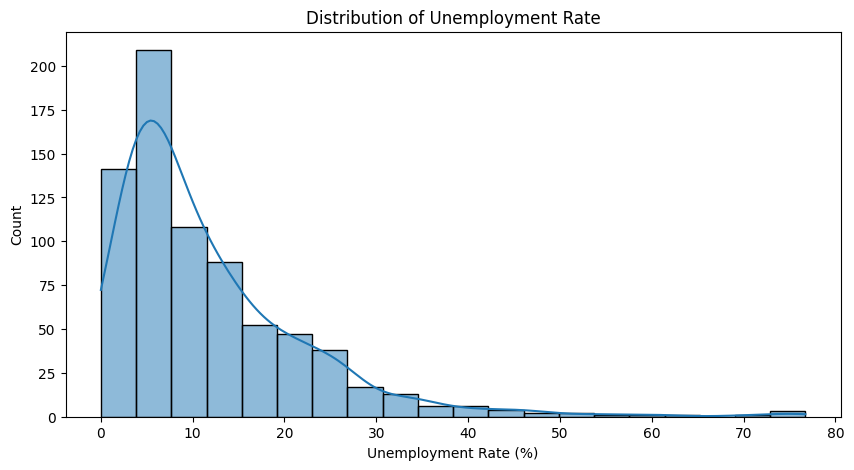

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Count')

plt.show()

# Observation:
 Most unemployment rates are concentrated in the lower range, while a few regions experienced significantly higher unemployment rates.

# 6. Top 10 Regions with Highest Unemployment

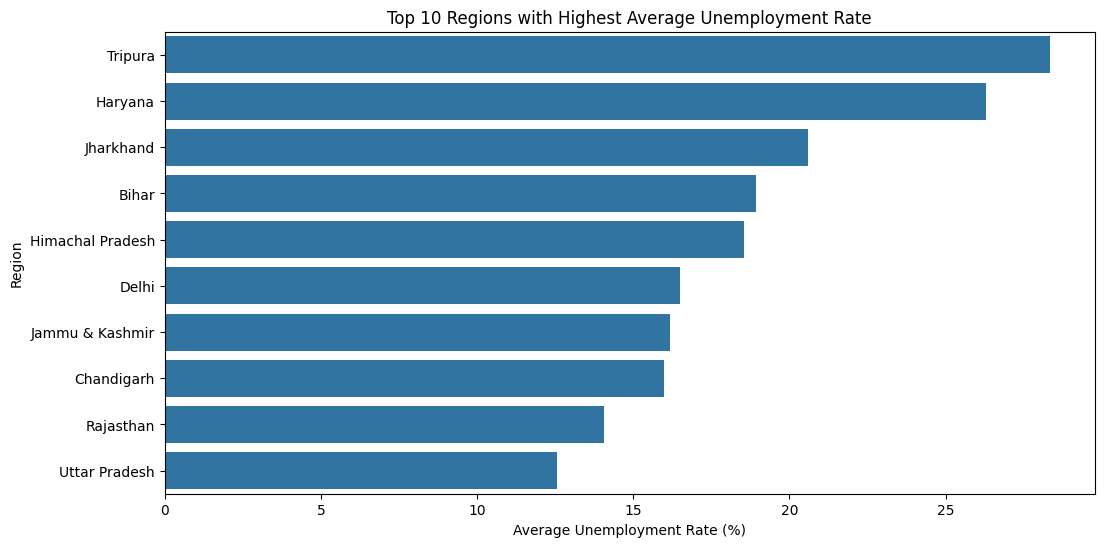

In [15]:
top_regions = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top_regions = top_regions.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_regions.values, y=top_regions.index)

plt.title('Top 10 Regions with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.show()

# Observation:
The graph highlights the regions with the highest average unemployment rates. These regions may require additional employment opportunities and economic support.

# 7. Urban vs Rural Analysis

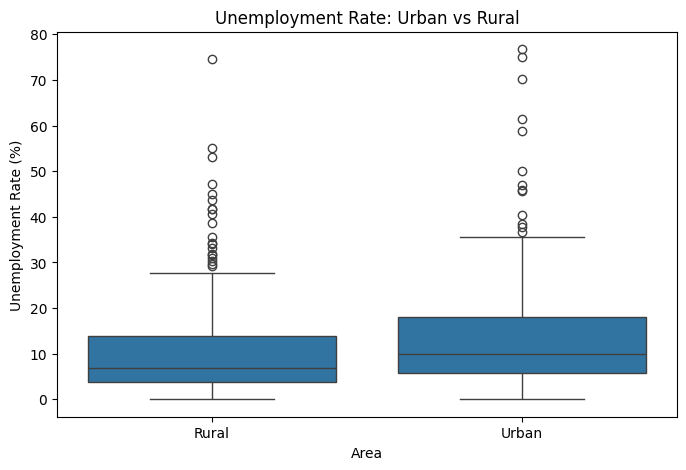

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title('Unemployment Rate: Urban vs Rural')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')

plt.show()

# Observation:
The boxplot compares unemployment rates between urban and rural areas. Any visible difference may indicate variations in employment opportunities across these areas.

# 8. Correlation Heatmap

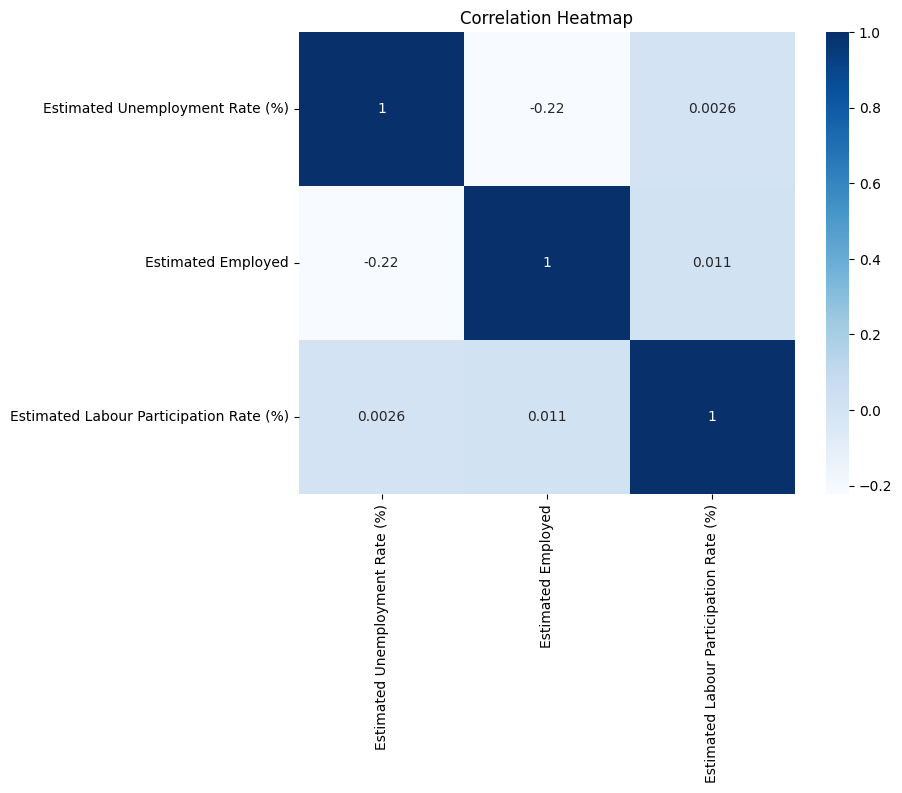

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=['float64']).corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

# Observation:
The heatmap shows the correlation between unemployment rate, employment, and labour participation rate. Strong positive or negative correlations indicate relationships between these variables.

# **Conclusion**

This project analyzed unemployment trends in India using Python. Data cleaning was performed to remove missing values and prepare the dataset for analysis. Various visualizations were created to understand the distribution of unemployment rates, identify regions with high unemployment, compare urban and rural unemployment patterns, and examine correlations between different employment-related factors. The analysis provided valuable insights into unemployment trends and regional variations across India.